# Estrategia de personalización en E-commerce

**Integrantes:** Pascal Salinas, Diego Soto, Matías Soto   |   **Fecha:** 19/05/2026

En esta tarea se resolverá un problema tanto de **regresión** como de **clasificación** sobre un dataset con datos sobre clientes de una empresa de e-commerce, para luego realizar un análisis exhaustivo, el cual se presentará al final de este notebook.

### Descripción del problema
Una empresa de e-commerce, a pesar de haber acumulado grandes volúmenes de datos sobre sus clientes, sigue teniendo una estrategia de marketing homogénea; es decir, todos sus clientes reciben las mismas promociones independientemente de sus preferencias. Es por ello que el área de analítica de esta empresa desea implementar una estrategia de segmentación inteligente, para generar recomendaciones según el comportamiento, el valor y la satisfacción del cliente.

Los datos muestran patrones contradictorios, lo cual ha resultado como un problema para la implementación de esta estrategia. Se han recopilado los siguientes datos:

|Variable|Tipo|Unidad|Descripción|
|-|-|-|-|
|`frecuencia`|Numérica|*Compras/Mes*|Número de compras mensuales|
|`gasto`|Numérica|*USD/Compra*|Monto promedio por compra|
|`visitas`|Numérica|*Visitas/Mes*|Número de visitas mensuales al sitio|
|`devoluciones`|Numérica|*Conteo/Mes*|Número de devoluciones mensuales|
|`satisfaccion_cliente`|Numérica|*Escala de 1-5*|Nivel de satisfacción percibida|
|`valor_cliente`|Numérica|*USD/Mes*|Valor total del cliente (`frecuencia` × `gasto`)|
|`cliente_premium`|Categórica|*True/False*|Cliente de alto valor (*percentil > 70*)|

El **objetivo principal del problema de regresión** será predecir el valor de cada cliente a partir de su comportamiento en la plataforma. La variable objetivo será `valor_cliente` y las features a utilizar son `frecuencia`, `gasto`, `visitas`, `devoluciones` y `satisfaccion_cliente`. Esta predicción le sirve a la empresa para estimar cuánto dinero generará un cliente en un mes y en base a ello priorizar recursos, diseñar ofertas personalizadas y proyectar ingresos.

El **objetivo principal del problema de clasificación** será predecir si un cliente pertenece al 30% de mayor valor dentro de la plataforma, es decir, si este es un cliente premium o no. La variable objetivo será `cliente_premium` y las features a utilizar son `frecuencia`, `gasto`, `visitas`, `devoluciones` y `satisfaccion_cliente`. No siempre es posible calcular el valor exacto de un cliente, pero si es posible identificar si pertenece al segmento de más alto valor para la plataforma. Esta clasificación le permite al equipo de marketing activar estrategias diferenciadas, como descuentos exclusivos o atención prioritaria, sin necesidad de conocer el monto exacto del gasto.

## Problema de regresión

Para la resolución de este problema, se utilizó un modelo de regresión lineal `LinearRegression` de la librería **scikit-learn**. Los datos fueron divididos en un 80% para entrenamiento y un 20% para pruebas.

##### Primero, importamos las librerías correspondientes

In [ ]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# --------------- #
# Regresión lineal para el problema de regresión
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# extraemos los datos
data = pd.read_csv("dataset.csv", sep=";")
data.head(3)

,frecuencia,gasto,visitas,devoluciones,satisfaccion_cliente,valor_cliente,cliente_premium
0,4.32,30.92,27.89,2.93,1.35,275.00,False
1,3.13,166.09,31.43,1.98,3.58,181.24,False
2,4.10,98.78,64.90,4.48,2.27,419.52,True


##### Ahora, verificamos los valores de $NaN$

In [3]:
# verificamos los valores NaN, o que no se pueden aceptar
print(data.isnull().sum())

frecuencia              5
gasto                   5
visitas                 5
devoluciones            5
satisfaccion_cliente    5
valor_cliente           5
cliente_premium         5
dtype: int64


##### Como son relativamente pocos valores NaN, podemos limparlos

In [4]:
data = data.dropna()
print(data.isnull().sum()) # volvemos a contar

frecuencia              0
gasto                   0
visitas                 0
devoluciones            0
satisfaccion_cliente    0
valor_cliente           0
cliente_premium         0
dtype: int64


##### Bien, ahora nuestro problema de regresión será predecir $valor\_cliente$ a partir de $(frecuencia,\ gasto)$

In [5]:
# Separamos los datos entonces
X = data[[
    "frecuencia", "gasto", "visitas", "devoluciones", "satisfaccion_cliente"
]]
Y = data[
    "valor_cliente"
]
# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

##### Creamos un modelo de regresión lineal y lo entrenamos

In [6]:
# Creamos el modelo de regresión lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### Ahora, podemos realizar predicciones (testear el modelo)

In [7]:
# Hacemos predicciones
y_pred = lin_reg.predict(X_test)

##### Calculamos las métricas de evaluación

In [8]:
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
# ---------------------------------------- #
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MSE: 47308.62311544419
MAE: 160.28551353607708
RMSE: 217.5054553693865
R²: 0.8116225071675056


##### Notar que $R^2>0.8$, por ende se tiene un modelo con "Excelente ajuste".

##### Comparamos con la desviación estándar de y_test

In [9]:
# Comparar con la desviación estándar de y_test
std_y_test = np.std(Y_test)
print(f"Desviación estándar de y_test: {std_y_test}")

Desviación estándar de y_test: 501.13605283247614


##### Visualizamos los datos y la línea de regresión

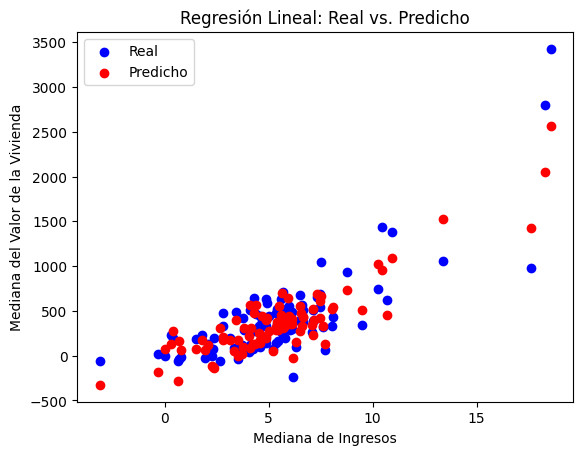

In [10]:
# Visualizar la relación entre valor_cliente y una de las características (frecuencia, gasto, ...)
plt.scatter(X_test['frecuencia'], Y_test, color='blue', label='Real')
plt.scatter(X_test['frecuencia'], y_pred, color='red', label='Predicho')
plt.xlabel('Mediana de Ingresos')
plt.ylabel('Mediana del Valor de la Vivienda')
plt.title('Regresión Lineal: Real vs. Predicho')
plt.legend()
plt.show()

### Análisis
> nada que ver aquí, por ahora...

## Problema de clasificación


In [ ]:
# Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Métricas de clasificación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Preprocesamiento de los datos
from sklearn.preprocessing import StandardScaler

# Visualización del árbol de decisión
from sklearn.tree import plot_tree